In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

#model
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
import joblib

In [2]:
import sys
print(sys.executable)

import site
print(site.getsitepackages())


c:\python\data-mining-project\.venv\Scripts\python.exe
['c:\\python\\data-mining-project\\.venv', 'c:\\python\\data-mining-project\\.venv\\Lib\\site-packages']


In [3]:
df = pd.read_csv("diabetesBRFSS.csv")
FEATURES = [
    'HighBP','HighChol','CholCheck','BMI','Smoker',
    'Stroke','HeartDiseaseorAttack','PhysActivity',
    'Fruits','Veggies','GenHlth','Age'
]
TARGET = 'Diabetes_binary'

print("Kolom yang dipakai:\n", FEATURES + [TARGET])

Kolom yang dipakai:
 ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'Age', 'Diabetes_binary']


# EDA

In [4]:
display(df[FEATURES + [TARGET]].head())
display(df[FEATURES + [TARGET]].tail())

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,Age,Diabetes_binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,9.0,0.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,7.0,0.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,9.0,0.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,11.0,0.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,11.0,0.0


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,Age,Diabetes_binary
253675,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,5.0,0.0
253676,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,11.0,1.0
253677,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0
253678,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,7.0,0.0
253679,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,9.0,1.0


In [5]:
df_sub = df[FEATURES + [TARGET]]
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                253680 non-null  float64
 1   HighChol              253680 non-null  float64
 2   CholCheck             253680 non-null  float64
 3   BMI                   253680 non-null  float64
 4   Smoker                253680 non-null  float64
 5   Stroke                253680 non-null  float64
 6   HeartDiseaseorAttack  253680 non-null  float64
 7   PhysActivity          253680 non-null  float64
 8   Fruits                253680 non-null  float64
 9   Veggies               253680 non-null  float64
 10  GenHlth               253680 non-null  float64
 11  Age                   253680 non-null  float64
 12  Diabetes_binary       253680 non-null  float64
dtypes: float64(13)
memory usage: 25.2 MB


In [6]:
df_sub.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,Age,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,2.511392,8.032119,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,1.068477,3.054220,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,6.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,8.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,10.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,13.000000,1.000000


In [7]:
df_sub.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
GenHlth                 0
Age                     0
Diabetes_binary         0
dtype: int64

In [8]:
binary_features = [
    'HighBP','HighChol','CholCheck','Smoker',
    'Stroke','HeartDiseaseorAttack','PhysActivity',
    'Fruits','Veggies'
]
for col in binary_features:
    print(f"\n--- {col} ---")
    print("Count:")
    print(df[col].value_counts())
    print("\nProportion:")
    print(df[col].value_counts(normalize=True))


--- HighBP ---
Count:
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64

Proportion:
HighBP
0.0    0.570999
1.0    0.429001
Name: proportion, dtype: float64

--- HighChol ---
Count:
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64

Proportion:
HighChol
0.0    0.575879
1.0    0.424121
Name: proportion, dtype: float64

--- CholCheck ---
Count:
CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64

Proportion:
CholCheck
1.0    0.96267
0.0    0.03733
Name: proportion, dtype: float64

--- Smoker ---
Count:
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

Proportion:
Smoker
0.0    0.556831
1.0    0.443169
Name: proportion, dtype: float64

--- Stroke ---
Count:
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64

Proportion:
Stroke
0.0    0.959429
1.0    0.040571
Name: proportion, dtype: float64

--- HeartDiseaseorAttack ---
Count:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

Proportion:
HeartDiseaseorAtt

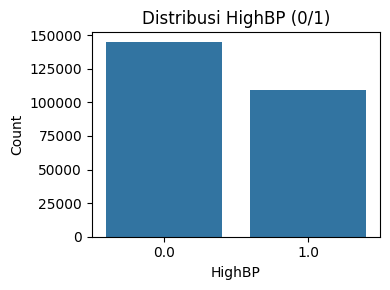

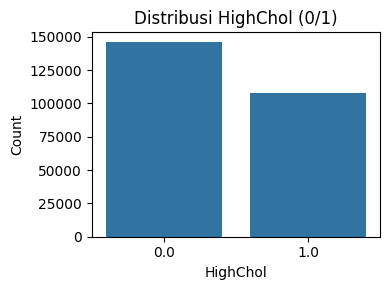

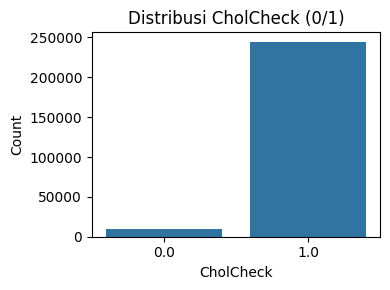

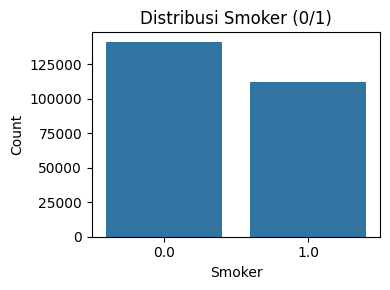

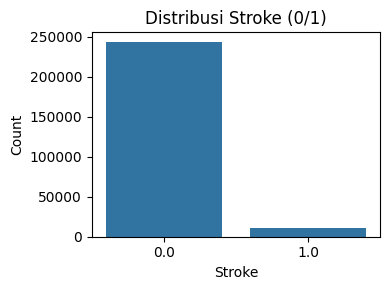

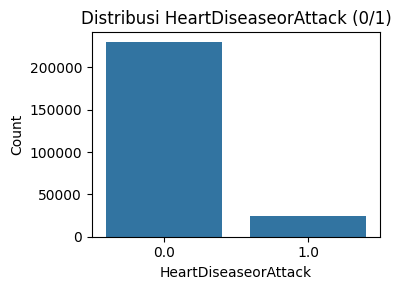

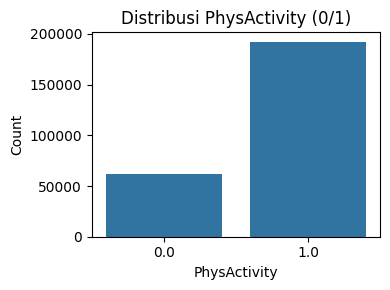

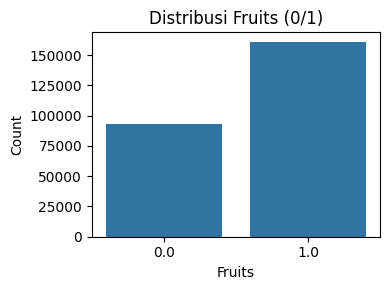

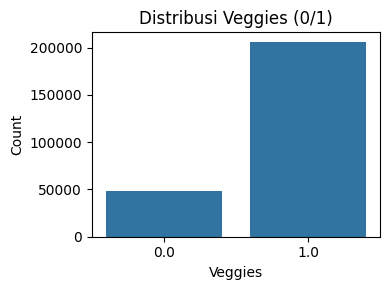

In [9]:
for col in binary_features:
    plt.figure(figsize=(4,3))
    sns.countplot(x=df[col])
    plt.title(f"Distribusi {col} (0/1)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [10]:
print("\n===== KORELASI FITUR TERHADAP TARGET (Diabetes_binary) =====")
corr_target = df_sub.corr()[TARGET].sort_values(ascending=False)
print(corr_target)


===== KORELASI FITUR TERHADAP TARGET (Diabetes_binary) =====
Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
Stroke                  0.105816
CholCheck               0.064761
Smoker                  0.060789
Fruits                 -0.040779
Veggies                -0.056584
PhysActivity           -0.118133
Name: Diabetes_binary, dtype: float64


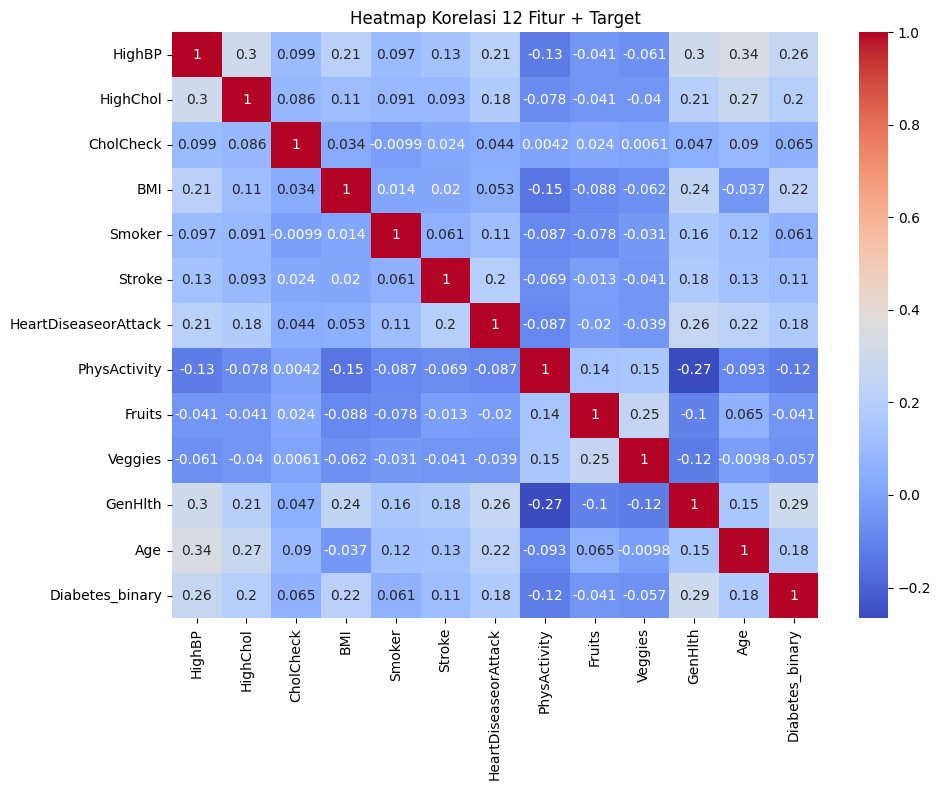

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df_sub.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi 12 Fitur + Target")
plt.tight_layout()
plt.show()

In [12]:
print("\n===== CROSSTAB FITUR BINARY vs TARGET =====")
for col in binary_features:
    print(f"\n--- {col} vs {TARGET} (proporsi per nilai {col}) ---")
    ct = pd.crosstab(df[col], df[TARGET], normalize='index')
    print(ct)


===== CROSSTAB FITUR BINARY vs TARGET =====

--- HighBP vs Diabetes_binary (proporsi per nilai HighBP) ---
Diabetes_binary       0.0       1.0
HighBP                             
0.0              0.939648  0.060352
1.0              0.755543  0.244457

--- HighChol vs Diabetes_binary (proporsi per nilai HighChol) ---
Diabetes_binary       0.0       1.0
HighChol                           
0.0              0.920186  0.079814
1.0              0.779851  0.220149

--- CholCheck vs Diabetes_binary (proporsi per nilai CholCheck) ---
Diabetes_binary       0.0       1.0
CholCheck                          
0.0              0.974551  0.025449
1.0              0.856251  0.143749

--- Smoker vs Diabetes_binary (proporsi per nilai Smoker) ---
Diabetes_binary       0.0       1.0
Smoker                             
0.0              0.879447  0.120553
1.0              0.837071  0.162929

--- Stroke vs Diabetes_binary (proporsi per nilai Stroke) ---
Diabetes_binary       0.0       1.0
Stroke            

In [13]:
df['BMI_bin'] = pd.cut(
    df['BMI'],
    bins=[0,18.5,25,30,35,100],
    labels=['underweight','normal','overweight','obese','very_obese']
)

print("\n--- BMI_bin vs Diabetes_binary (proporsi) ---")
ct_bmi = pd.crosstab(df['BMI_bin'], df[TARGET], normalize='index')
print(ct_bmi)



--- BMI_bin vs Diabetes_binary (proporsi) ---
Diabetes_binary       0.0       1.0
BMI_bin                            
underweight      0.945955  0.054045
normal           0.937525  0.062475
overweight       0.873179  0.126821
obese            0.788473  0.211527
very_obese       0.693599  0.306401


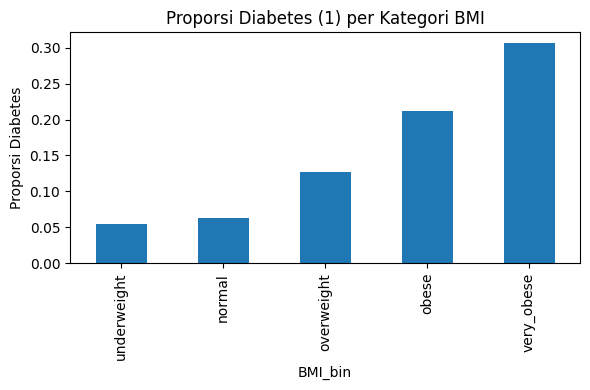

In [14]:
plt.figure(figsize=(6,4))
ct_bmi[1].plot(kind='bar')
plt.title("Proporsi Diabetes (1) per Kategori BMI")
plt.ylabel("Proporsi Diabetes")
plt.xlabel("BMI_bin")
plt.tight_layout()
plt.show()


--- GenHlth vs Diabetes_binary (proporsi) ---
Diabetes_binary       0.0       1.0
GenHlth                            
1.0              0.974834  0.025166
2.0              0.928371  0.071629
3.0              0.822106  0.177894
4.0              0.689895  0.310105
5.0              0.621058  0.378942


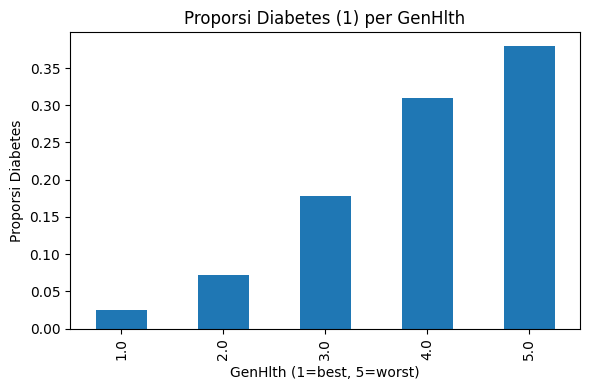

In [15]:
print("\n--- GenHlth vs Diabetes_binary (proporsi) ---")
ct_gen = pd.crosstab(df['GenHlth'], df[TARGET], normalize='index')
print(ct_gen)

plt.figure(figsize=(6,4))
ct_gen[1].plot(kind='bar')
plt.title("Proporsi Diabetes (1) per GenHlth")
plt.ylabel("Proporsi Diabetes")
plt.xlabel("GenHlth (1=best, 5=worst)")
plt.tight_layout()
plt.show()


--- Age vs Diabetes_binary (proporsi) ---
Diabetes_binary       0.0       1.0
Age                                
1.0              0.986316  0.013684
2.0              0.981574  0.018426
3.0              0.971770  0.028230
4.0              0.954713  0.045287
5.0              0.934951  0.065049
6.0              0.912105  0.087895
7.0              0.882648  0.117352
8.0              0.861735  0.138265
9.0              0.827548  0.172452
10.0             0.796297  0.203703
11.0             0.781541  0.218459
12.0             0.787046  0.212954
13.0             0.815182  0.184818


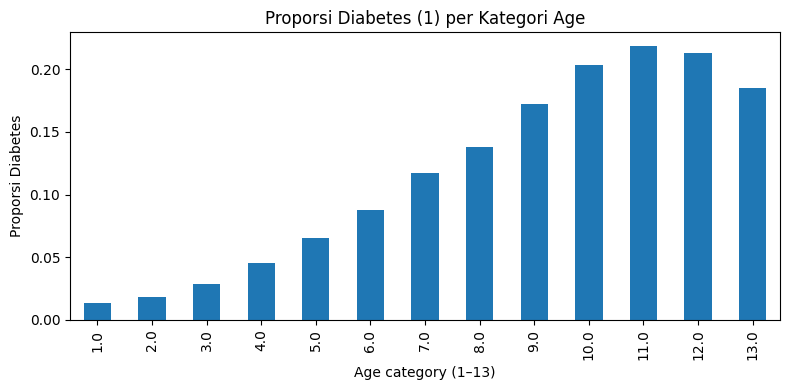

In [16]:
print("\n--- Age vs Diabetes_binary (proporsi) ---")
ct_age = pd.crosstab(df['Age'], df[TARGET], normalize='index')
print(ct_age)

plt.figure(figsize=(8,4))
ct_age[1].plot(kind='bar')
plt.title("Proporsi Diabetes (1) per Kategori Age")
plt.ylabel("Proporsi Diabetes")
plt.xlabel("Age category (1–13)")
plt.tight_layout()
plt.show()

# PREPROCESSING

In [17]:
# Buat dataframe kerja hanya dengan 12 fitur + target
df_model = df[FEATURES + [TARGET]].copy()

print("Shape df_model:", df_model.shape)
print("Kolom df_model:", df_model.columns.tolist())

Shape df_model: (253680, 13)
Kolom df_model: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'Age', 'Diabetes_binary']


In [18]:
#CEK CLASS IMBALANCE + HITUNG CLASS WEIGHTS
print("\n===== DISTRIBUSI KELAS TARGET =====")
print(df_model[TARGET].value_counts())
print("\nProporsi kelas:")
print(df_model[TARGET].value_counts(normalize=True))


===== DISTRIBUSI KELAS TARGET =====
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Proporsi kelas:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


In [19]:
# Hitung class weight untuk dipakai nanti di model.fit()
classes = np.unique(df_model[TARGET])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_model[TARGET].values
)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}

print("CLASS WEIGHTS")
print(class_weight_dict)

CLASS WEIGHTS
{np.float64(0.0): np.float64(0.5809447910082717), np.float64(1.0): np.float64(3.5885248684433884)}


In [20]:
# Pisahkan x dan y
X = df_model[FEATURES].values
y = df_model[TARGET].values

print("\nShape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (253680, 12)
Shape y: (253680,)


In [21]:
# Training + Validation + Test
# Pertama: pisah train + temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,          # 80% train, 20% sisanya
    random_state=42,
    stratify=y
)

# Kedua: pisah val + test dari temp (masing-masing 10% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # 10% val, 10% test dari total
    random_state=42,
    stratify=y_temp
)

print("\n===== SHAPE SPLIT DATA =====")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

print("\nDistribusi kelas di TRAIN:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nDistribusi kelas di VAL:")
print(pd.Series(y_val).value_counts(normalize=True))
print("\nDistribusi kelas di TEST:")
print(pd.Series(y_test).value_counts(normalize=True))


===== SHAPE SPLIT DATA =====
X_train: (202944, 12)  y_train: (202944,)
X_val  : (25368, 12)  y_val  : (25368,)
X_test : (25368, 12)  y_test : (25368,)

Distribusi kelas di TRAIN:
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Distribusi kelas di VAL:
0.0    0.860651
1.0    0.139349
Name: proportion, dtype: float64

Distribusi kelas di TEST:
0.0    0.860691
1.0    0.139309
Name: proportion, dtype: float64


In [22]:
#SCALING / NORMALISASI FITUR NUMERIK
scaler = StandardScaler()

# Fit hanya di TRAIN, lalu transform train/val/test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape  :", X_val_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (202944, 12)
X_val_scaled shape  : (25368, 12)
X_test_scaled shape : (25368, 12)


In [23]:
sns.set(style="whitegrid")

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

In [24]:
# Membangun arsitektur DNN 
input_dim = X_train_scaled.shape[1]
print("Input dimension:", input_dim)

model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid') 
])

Input dimension: 12


c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,681 (14.38 KB)

 Non-trainable params: 224 (896.00 B)

In [26]:
# EarlyStopping + Training Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6612 - loss: 0.5655 - val_accuracy: 0.6991 - val_loss: 0.5312
Epoch 2/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6956 - loss: 0.5267 - val_accuracy: 0.6937 - val_loss: 0.5375
Epoch 3/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6998 - loss: 0.5227 - val_accuracy: 0.6982 - val_loss: 0.5271
Epoch 4/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7009 - loss: 0.5195 - val_accuracy: 0.7200 - val_loss: 0.5097
Epoch 5/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7036 - loss: 0.5187 - val_accuracy: 0.7164 - val_loss: 0.5199
Epoch 6/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7044 - loss: 0.5179 - val_accuracy: 0.7108 - val_loss: 0.5198
Epoch 7/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7073 - loss: 0.5165 - val_accuracy: 0.7139 - val_loss: 0.5218
Epoch 8/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7085 - loss: 0.5169

,accuracy,loss,val_accuracy,val_loss
9,0.712201,0.515576,0.702460,0.530168
10,0.709812,0.515199,0.709910,0.524358
11,0.712492,0.514988,0.717124,0.515713
12,0.713009,0.514941,0.713576,0.516983
13,0.710733,0.514472,0.719529,0.514492


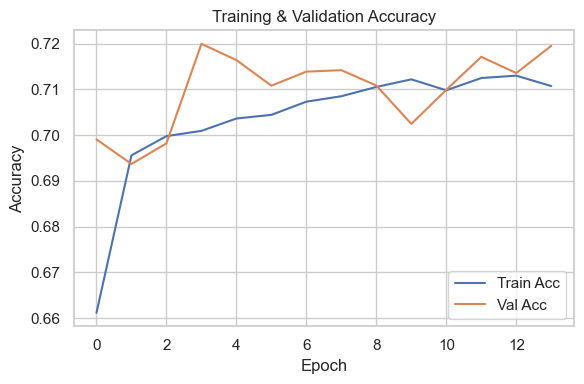

In [27]:
#Plot history training (accuracy & loss)
import pandas as pd
history_df = pd.DataFrame(history.history)
display(history_df.tail())

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


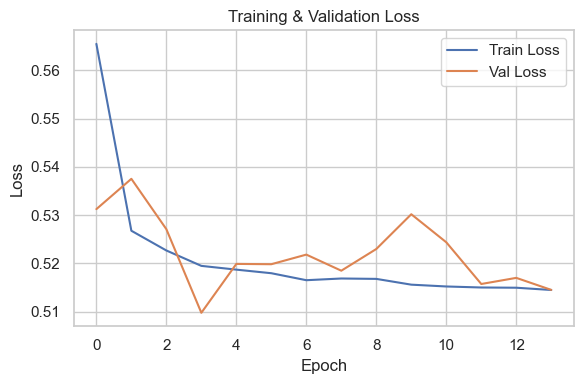

In [28]:
# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Evaluasi: loss, accuracy, precision, recall, F1, ROC-AUC
# Prediksi probabilitas
y_test_prob = model.predict(X_test_scaled).ravel()

793/793 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [30]:
# Threshold default 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

In [31]:
# Metrik
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_prob)

print(" METRIK TEST SET ")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

 METRIK TEST SET 
Accuracy : 0.7117
Precision: 0.2958
Recall   : 0.7745
F1-score : 0.4281
ROC-AUC  : 0.8154

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.95      0.70      0.81     21834
         1.0       0.30      0.77      0.43      3534

    accuracy                           0.71     25368
   macro avg       0.62      0.74      0.62     25368
weighted avg       0.86      0.71      0.75     25368



Confusion Matrix:
 [[15318  6516]
 [  797  2737]]


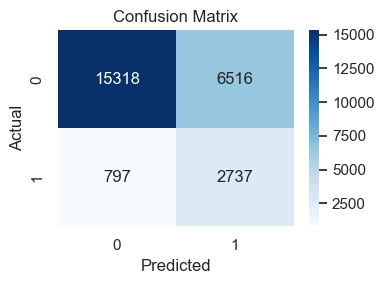

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

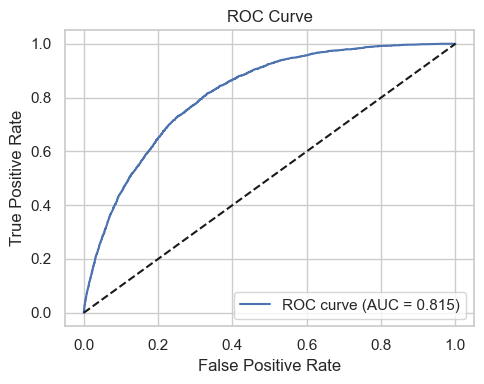

In [33]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
#Simpan model & scaler
# Simpan scaler
joblib.dump(scaler, "scaler_diabetes.pkl")
print("Scaler disimpan sebagai scaler_diabetes.pkl")

# Simpan model Keras
model.save("diabetes_dnn_binary.h5")
print("Model disimpan sebagai diabetes_dnn_binary.h5")

Scaler disimpan sebagai scaler_diabetes.pkl
Model disimpan sebagai diabetes_dnn_binary.h5


In [35]:
# INSTALL & IMPORT SHAP

import shap
import numpy as np

shap.initjs()

c:\python\data-mining-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
# Ambil 100 sampel dari train sebagai background
np.random.seed(42)
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

f = lambda x: model.predict(x).ravel()

explainer = shap.KernelExplainer(f, background)

# Ambil hanya 50 sampel test buat interpretasi
X_test_sample = X_test_scaled[:50]

# Batasi nsamples biar gak terlalu berat
shap_values = explainer.shap_values(X_test_sample, nsamples=100)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


  2%|▏         | 1/50 [00:02<02:00,  2.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


  4%|▍         | 2/50 [00:04<01:53,  2.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


  6%|▌         | 3/50 [00:07<01:52,  2.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


  8%|▊         | 4/50 [00:09<01:51,  2.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 10%|█         | 5/50 [00:11<01:45,  2.34s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 12%|█▏        | 6/50 [00:13<01:39,  2.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 14%|█▍        | 7/50 [00:16<01:35,  2.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 16%|█▌        | 8/50 [00:19<01:45,  2.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 18%|█▊        | 9/50 [00:22<01:49,  2.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 20%|██        | 10/50 [00:25<01:51,  2.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 22%|██▏       | 11/50 [00:27<01:39,  2.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 24%|██▍       | 12/50 [00:30<01:43,  2.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


 26%|██▌       | 13/50 [00:32<01:32,  2.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 28%|██▊       | 14/50 [00:34<01:25,  2.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 30%|███       | 15/50 [00:37<01:31,  2.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 32%|███▏      | 16/50 [00:40<01:33,  2.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


 34%|███▍      | 17/50 [00:43<01:26,  2.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 36%|███▌      | 18/50 [00:46<01:28,  2.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 38%|███▊      | 19/50 [00:48<01:19,  2.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 40%|████      | 20/50 [00:51<01:22,  2.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 42%|████▏     | 21/50 [00:54<01:22,  2.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 44%|████▍     | 22/50 [00:56<01:14,  2.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 46%|████▌     | 23/50 [00:58<01:07,  2.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 48%|████▊     | 24/50 [01:01<01:03,  2.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 50%|█████     | 25/50 [01:03<00:58,  2.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 52%|█████▏    | 26/50 [01:05<00:55,  2.32s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 54%|█████▍    | 27/50 [01:08<00:58,  2.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 56%|█████▌    | 28/50 [01:11<00:59,  2.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 58%|█████▊    | 29/50 [01:13<00:53,  2.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 60%|██████    | 30/50 [01:15<00:47,  2.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


 62%|██████▏   | 31/50 [01:17<00:41,  2.19s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 64%|██████▍   | 32/50 [01:19<00:38,  2.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 66%|██████▌   | 33/50 [01:22<00:40,  2.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 68%|██████▊   | 34/50 [01:25<00:41,  2.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 70%|███████   | 35/50 [01:27<00:37,  2.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 72%|███████▏  | 36/50 [01:30<00:34,  2.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 74%|███████▍  | 37/50 [01:32<00:30,  2.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 76%|███████▌  | 38/50 [01:34<00:27,  2.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 78%|███████▊  | 39/50 [01:37<00:27,  2.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


 80%|████████  | 40/50 [01:40<00:24,  2.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 82%|████████▏ | 41/50 [01:42<00:21,  2.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


 84%|████████▍ | 42/50 [01:44<00:18,  2.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 86%|████████▌ | 43/50 [01:46<00:16,  2.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 88%|████████▊ | 44/50 [01:48<00:13,  2.23s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 90%|█████████ | 45/50 [01:50<00:11,  2.23s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 92%|█████████▏| 46/50 [01:53<00:08,  2.21s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 94%|█████████▍| 47/50 [01:55<00:06,  2.24s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


 96%|█████████▌| 48/50 [01:57<00:04,  2.23s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


 98%|█████████▊| 49/50 [01:59<00:02,  2.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


100%|██████████| 50/50 [02:02<00:00,  2.45s/it]


C:\Users\Arifi\AppData\Local\Temp\ipykernel_11780\1300718938.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


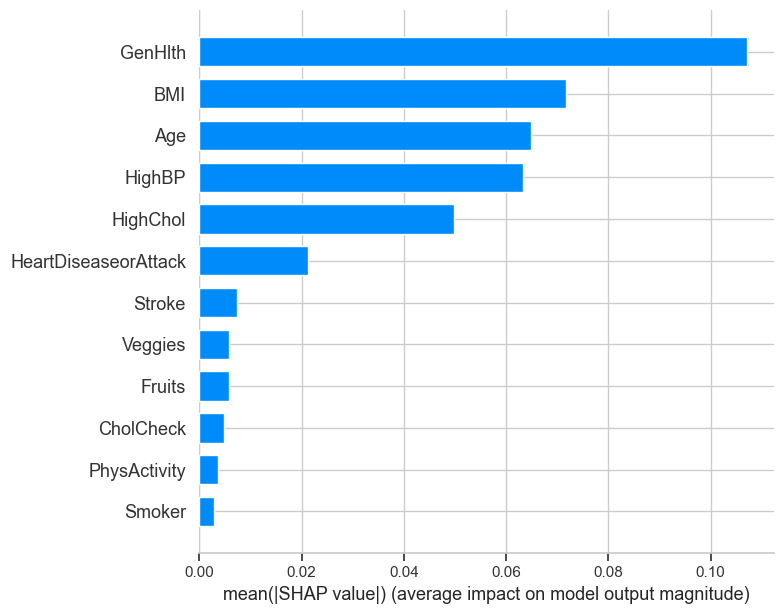

In [37]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=[
        'HighBP','HighChol','CholCheck','BMI','Smoker',
        'Stroke','HeartDiseaseorAttack','PhysActivity',
        'Fruits','Veggies','GenHlth','Age'
    ],
    plot_type='bar'
)

C:\Users\Arifi\AppData\Local\Temp\ipykernel_11780\534828583.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


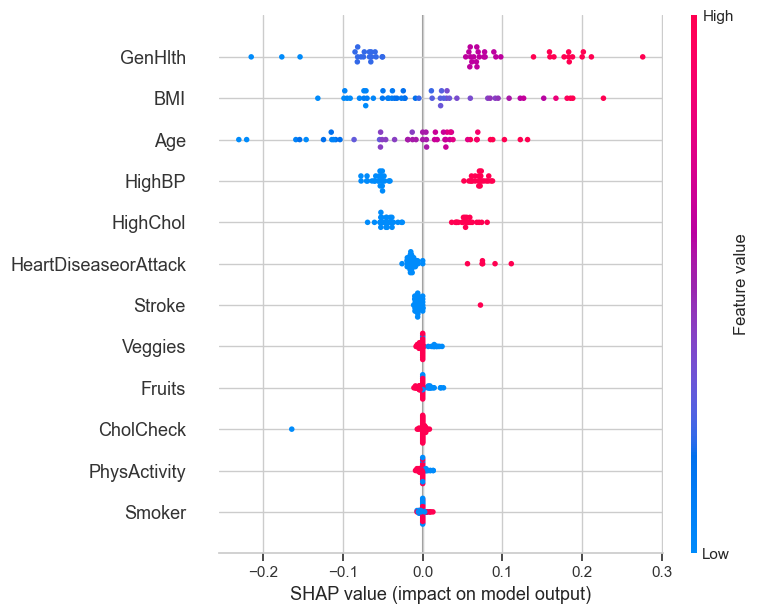

In [38]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=[
        'HighBP','HighChol','CholCheck','BMI','Smoker',
        'Stroke','HeartDiseaseorAttack','PhysActivity',
        'Fruits','Veggies','GenHlth','Age'
    ]
)


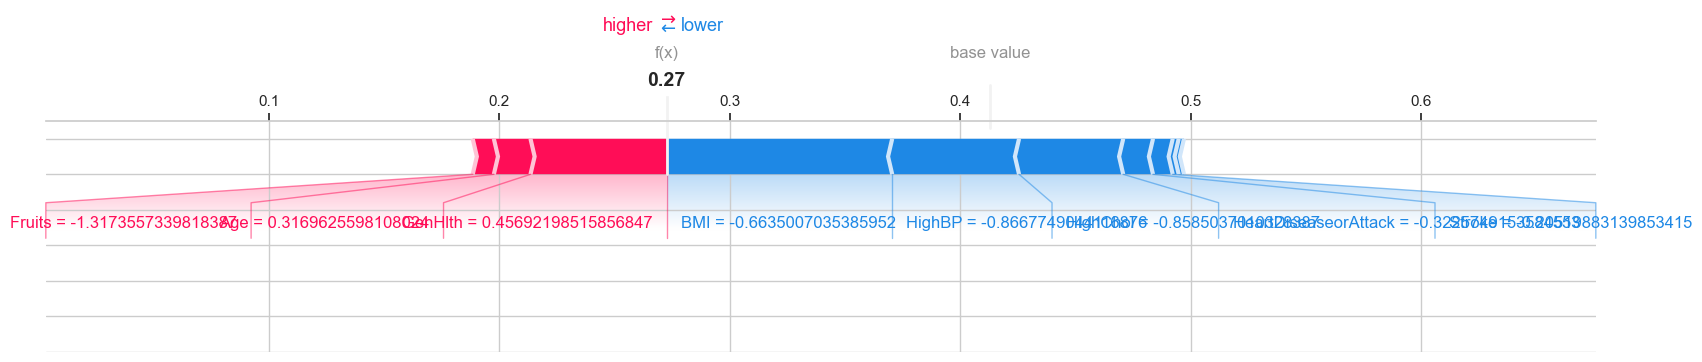

In [39]:
i = 0 
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test_sample[i],
    feature_names=[
        'HighBP','HighChol','CholCheck','BMI','Smoker',
        'Stroke','HeartDiseaseorAttack','PhysActivity',
        'Fruits','Veggies','GenHlth','Age'
    ],
    matplotlib=True
)
